In [22]:
import pedpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import from_wkt, Polygon
import json
from pedpy import compute_voronoi_density
from pedpy import compute_individual_voronoi_polygons
from pathlib import Path
from pedpy import (
    Cutoff,
    SpeedCalculation,
    compute_individual_speed,
    compute_individual_voronoi_polygons,
)
from pedpy import FRAME_COL, ID_COL, POINT_COL, DENSITY_COL
from pedpy import Cutoff
from pedpy import plot_voronoi_cells
import seaborn as sns

In [23]:
def read_json_file(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [24]:
# Original exterior ring
exterior = [
    (-8.88, -11.1),
    (8.3, -11.1),
    (8.3, 27.95),
    (-8.88, 27.95),
    (-8.88, -11.1),
]

# Interior rings (excluding the door)
interior_rings = [
    # Left cutout
    [
        (-7, -11),
        (-3.57, -3),
        (-3.57, 19.57),
        (-1.52, 19.57),
        (-1.37, 19.71),
        (-0.87, 19.71),
        (-0.72, 19.57),
        (-0.42, 19.57),
        (-0.42, 21.23),
        (-0.72, 21.23),
        (-0.87, 21.09),
        (-1.37, 21.09),
        (-1.52, 21.23),
        (-1.67, 21.23),
        (-1.67, 21.18),
        (-1.545, 21.18),
        (-1.42, 21.065),
        (-1.42, 19.735),
        (-1.545, 19.62),
        (-3.62, 19.62),
        (-3.59, -3),
        (-7, -11),
    ],
    # Right cutout
    [
        (7, -11),
        (3.57, -3),
        (3.64, 19.64),
        (1.47, 19.57),
        (1.32, 19.71),
        (0.82, 19.71),
        (0.67, 19.57),
        (0.38, 19.57),
        (0.38, 21.23),
        (0.67, 21.23),
        (0.82, 21.09),
        (1.32, 21.09),
        (1.47, 21.23),
        (1.62, 21.23),
        (1.62, 21.18),
        (1.495, 21.18),
        (1.37, 21.065),
        (1.37, 19.735),
        (1.495, 19.62),
        (3.69, 19.69),
        (3.62, -3),
        (7, -11),
    ],
    # Bottom strip
    [(-6.8, -10.8), (6.8, -10.8), (6.8, -10.6), (-6.8, -10.6), (-6.8, -10.8)],
]

# Door coordinates
#door = [(-0.4, 19.57), (0.37, 19.57), (0.37, 19.3), (-0.4, 19.3), (-0.4, 19.57)]
# Create closed geometry (with door)
geometry = Polygon(exterior, interior_rings)

walkable_area = pedpy.WalkableArea(geometry)

inifile = "files/m1C070.json"
data = read_json_file(inifile)
measurement_line = pedpy.MeasurementLine(data["measurement_line"]["vertices"])
measurement_area = pedpy.MeasurementArea(data["measurement_area"]["vertices"])
measurement_area = pedpy.MeasurementArea(
    [[-0.72, 17], [0.67, 17], [0.67, 16], [-0.72, 16]]
)

#pedpy.plot_measurement_setup(traj=traj, walkable_area=walkable_area, measurement_lines=[measurement_line], measurement_areas=[measurement_area]).axis('equal')

In [25]:
def process_experiment_file(
    filename,
    walkable_area,
    fps=50,
    polygon_cutoff_radius=1,
    polygon_quad_segments=3,
    title=None,
    file_type="experiment",
):

    if file_type == "experiment":
        if not title:
            title = filename.split("_")[1].capitalize()
        df = pd.read_csv(
            filename, sep="\t", names=["id", "frame", "x", "y", "z", "m"], comment="#"
        )
        traj = pedpy.TrajectoryData(df, frame_rate=fps)
        print(filename, traj.frame_rate)
    elif file_type == "simulation":
        traj = pedpy.load_trajectory_from_jupedsim_sqlite(filename)
        df = traj.data
        print(filename, traj.frame_rate)

    print(f"Processing experiment: {title}")

    # --- Crossing Information Calculation ---
    # Filter rows where pedestrians have crossed (e.g., y >= 20)
    df_crossed = df[df["y"] >= 20].copy()

    # For each pedestrian (id), get the first frame where they cross.
    crossing_frames = df_crossed.groupby("id")["frame"].min().rename("crossing_frame")

    # Sort crossing frames to determine the order.
    crossing_frames_sorted = crossing_frames.sort_values()

    # Create a series that indicates crossing order (1 for first, 2 for second, etc.)
    crossing_order = pd.Series(
        range(1, len(crossing_frames_sorted) + 1),
        index=crossing_frames_sorted.index,
        name="crossing_order",
    )

    crossing_info = pd.concat([crossing_frames, crossing_order], axis=1)

    # --- Voronoi Polygon and Density Computation ---
    # Compute individual Voronoi polygons; ensure 'walkable_area' is defined properly.
    individual = compute_individual_voronoi_polygons(
        traj_data=traj,
        walkable_area=walkable_area,
        cut_off=Cutoff(
            radius=polygon_cutoff_radius, quad_segments=polygon_quad_segments
        ),
    )

    # Compute mean density over time (group by frame)
    density_over_time = (
        individual.groupby("frame")["density"].mean()#.rename("mean_individual_density")
    )

    # Compute mean density per agent (group by id)
    density_per_agent = (
        individual.groupby("id")["density"].mean()
    )

    # Compute polygon area for each individual.
    individual["area"] = individual["polygon"].apply(lambda poly: poly.area)

    # Compute mean polygon area per agent.
    area_per_agent = (
        individual.groupby("id")["area"].mean()
    )

    # --- Merging the Data ---
    # Create DataFrames from Series
    df_order = crossing_order.to_frame(name="order")
    df_density = density_per_agent.to_frame(name="density")
    df_area = area_per_agent.to_frame()

    # Merge on the 'id' index (make sure all series are indexed by id)
    df_merged = df_order.join(df_density, how="inner").join(df_area, how="inner")

    return df_merged, density_over_time, crossing_info, individual, title

In [26]:
experiment_file_low = "../trajectories_croma/1C070_cam6_cam5_frameshift0_Combined.txt"
experiment_file_high = "../trajectories_croma/2C070_cam6_cam5_frameshift0_Combined.txt"

# Process one experiment file (low motivation)
df_merged_low, density_over_time_low, crossing_info_low, individual_low, title_low = (
    process_experiment_file(experiment_file_low, walkable_area)
)

# Process another experiment file (high motivation)
(
    df_merged_high,
    density_over_time_high,
    crossing_info_high,
    individual_high,
    title_high,
) = process_experiment_file(experiment_file_high, walkable_area)

../trajectories_croma/1C070_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/1c070
../trajectories_croma/2C070_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/2c070


In [28]:
# date = "2025-04-02_12-26-06"
# date = "2025-04-02_14-19-46"
# date = "2025-04-02_17-56-08" # base model. M=1. Buffer=0
# date = "2025-04-04_12-13-24" # base model. M=1. Buffer=1
# date = "2025-04-04_16-27-46"
# date = "2025-05-29_06-02-41" # adjust buffer
# simulation_file = Path(f"files/variations/m1C070_base_{date}.sqlite")
# #-------
# date = "2025-05-29_06-49-55" # baseline_notbuffer buffer=0.5

# simulation_files =[
#      Path("files/variations/m1C070_baseline_notbuffer_base_2025-05-29_06-49-55.sqlite"),
#      Path("files/variations/m1C070_baseline_withbuffer_base_2025-05-29_06-52-00.sqlite"),
#      Path("files/variations/m1C070_lowvalue_withbuffer_base_2025-05-29_07-08-44.sqlite"),
#      Path("files/variations/m1C070_highvalue_withbuffer_base_2025-05-29_07-34-23.sqlite"),
#      Path("files/variations/m1C070_16highvalue_withbuffer_base_2025-05-29_07-29-40.sqlite"),
#      Path("files/variations/m1C070_32highvalue_withbuffer_base_2025-05-29_16-03-58.sqlite"),
#      Path("m1C070_32highvalue_withbuffer_Motiv_base_2025-06-24_11-00-45.txt")
# ]

# for simulation_file in simulation_files:
#     print(f"Processing simulation file: {simulation_file}")
#     if not simulation_file.exists():
#         print(f"File {simulation_file} does not exist. Skipping.")
#         continue
#     # Process each simulation file

#     (
#         df_merged_simulation,
#         density_over_time_simulation,
#         crossing_info_simulation,
#         individual_simulation,
#         title_simulation,
#     ) = process_experiment_file(
#         simulation_file, walkable_area, file_type="simulation", title="Simulation"
#     )
#     plt.figure(figsize=(6, 4))
#     plt.scatter(
#         df_merged_simulation["order"],
#         df_merged_simulation["area"],
#         color="blue",
#     )       
#     plt.xlabel("Crossing Order (1 = first to cross)")
#     plt.ylabel(r"Mean Area per Agent / $m^2$")
#     #plt.title(title_simulation)
#     max_order = df_merged_simulation["order"].max()
#     print(f"Max crossing order: {max_order}")
#     plt.xticks(range(1, max_order + 1, 20))
#     plt.ylim([0, 3])
#     plt.grid(True, alpha=0.3)
#     plt.savefig(f"index_area_figs/{simulation_file.stem}.png")
#     print(f"index_area_figs/{simulation_file.stem}.png")    
#     plt.show()

In [29]:
# plt.figure(figsize=(6, 4))
# plt.scatter(
#     df_merged_simulation["order"],
#     df_merged_simulation["area"],
#     color="blue",
# )
# print(f"Processing experiment: {title_simulation}")
# plt.xlabel("Crossing Order (1 = first to cross)")
# plt.ylabel(r"Mean Area per Agent / $m^2$")
# #plt.title(title_simulation)
# max_order = df_merged_simulation["order"].max()
# plt.xticks(range(1, max_order + 1, 20))
# plt.ylim([0, 3])
# plt.grid(True, alpha=0.3)
# plt.savefig(f"index_area_figs/area_order_{date}.png")
# print(f"index_area_figs/area_order_{date}.png")
# plt.show()

In [30]:
# print(simulation_file)
# fig, ax = plt.subplots(figsize=(8, 8))
# traj = pedpy.load_trajectory_from_jupedsim_sqlite(simulation_file)
# plot_voronoi_cells(
#     axes=ax,
#     voronoi_data=individual_simulation,
#     traj_data=traj,
#     frame=1000,
#     walkable_area=walkable_area,
#     color_by_column=DENSITY_COL,
#     show_colorbar=False,
#     vmin=0,
#     vmax=10,
# )
# ax.axis("equal")

Processing experiment: Croma/1c070


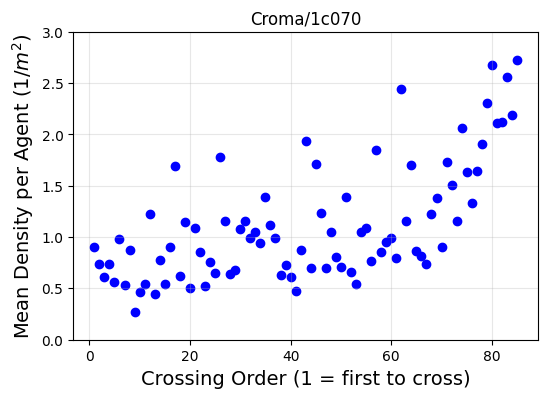

In [31]:
plt.figure(figsize=(6, 4))
plt.scatter(df_merged_low["order"], df_merged_low["area"], color="blue")
print(f"Processing experiment: {title_low}")
plt.xlabel("Crossing Order (1 = first to cross)", size=14)
plt.ylabel(r"Mean Density per Agent ($1/m^2$)", size=14)
plt.title(title_low)
#max_order = df_merged_simulation["order"].max()
#plt.xticks(range(1, max_order + 1,20))
plt.ylim([0, 3])
plt.grid(True, alpha=0.3)
plt.savefig(f"index_area_figs/area_order_{title_low.replace("/", "_")}.pdf", bbox_inches="tight")
plt.show()

Processing experiment: Croma/2c070


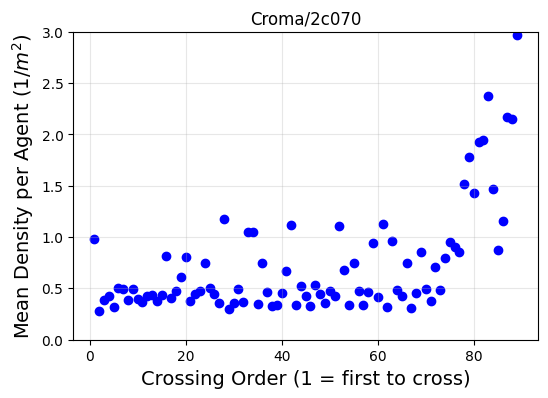

In [32]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_merged_high["order"], df_merged_high["area"], color="blue"
)
print(f"Processing experiment: {title_high}")
plt.xlabel("Crossing Order (1 = first to cross)", size=14)
plt.ylabel(r"Mean Density per Agent ($1/m^2$)", size=14)
plt.title(title_high)
plt.ylim([0, 3])
plt.grid(True, alpha=0.3)
plt.savefig(f"index_area_figs/area_order_{title_high.replace("/", "_")}.pdf", bbox_inches="tight")
plt.show()

In [33]:
def plot_density_distribution(density_over_time, title, palette="husl", ylim=1.5):
    # Set the color palette
    sns.set_palette(palette)

    # Create figure and axis objects with larger figure size and adjust the layout
    fig = plt.figure(figsize=(12, 6))
    # Create a gridspec layout with extra space on the right
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1])
    ax = fig.add_subplot(gs[0])

    # Plot histogram with KDE overlay
    sns.histplot(
        data=density_over_time,
        kde=True,
        bins=30,
        color="#3498db",
        fill=True,
        alpha=0.6,
        linewidth=2,
        stat="density",
        ax=ax,
    )

    # Enhance the plot styling
    ax.set_xlabel("Mean Individual Density (1/m²)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Distribution of {title} Density Over Time",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    # Customize grid
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.set_ylim([0,ylim])
    # Create a text box for statistics and legend in the right subplot
    stats_ax = fig.add_subplot(gs[1])
    stats_ax.axis("off")

    plt.tight_layout()
    return fig

In [ ]:
#fig_sim = plot_density_distribution(df_merged_simulation["density"], "simulation", ylim=1.4)

NameError: name 'df_merged_simulation' is not defined

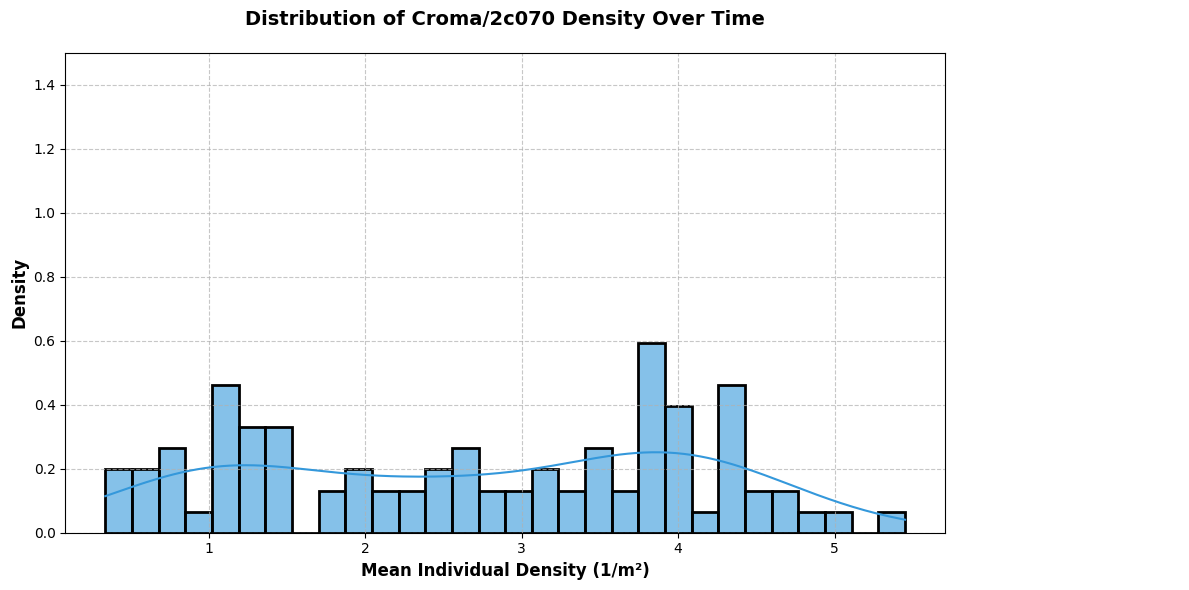

In [ ]:
#fig_high = plot_density_distribution(df_merged_high["density"], title_high)

In [ ]:
#fig_low = plot_density_distribution(df_merged_low["density"], title_low)

In [ ]:
# import statsmodels.api as sm

# X = df_merged_low["order"]
# y = df_merged_low["density"]

# # Add constant for intercept
# X_const = sm.add_constant(X)
# model = sm.OLS(y, X_const).fit()
# print(model.summary())

Processing experiment: Croma/2c070
../trajectories_croma/1C070_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/1c070
>>  index_area_figs/area_order_Croma_1c070.pdf


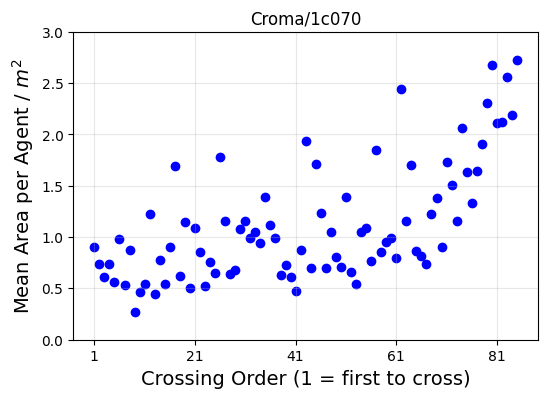

Processing experiment: Croma/2c070
../trajectories_croma/2C070_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/2c070
>>  index_area_figs/area_order_Croma_2c070.pdf


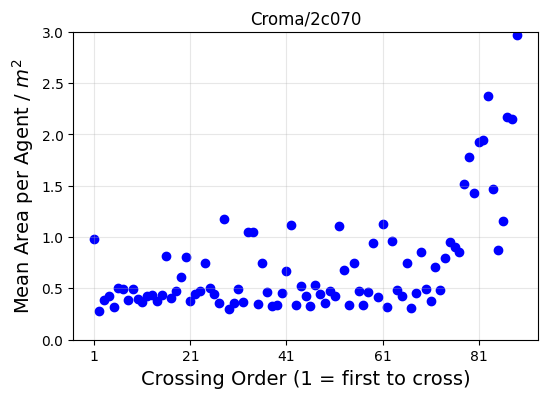

Processing experiment: Croma/2c070
../trajectories_croma/1C060_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/1c060
>>  index_area_figs/area_order_Croma_1c060.pdf


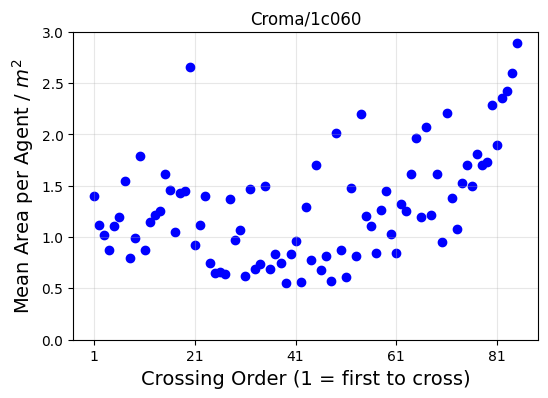

Processing experiment: Croma/2c070
../trajectories_croma/2C120_cam6_cam5_frameshift0_Combined.txt 50
Processing experiment: Croma/2c120
>>  index_area_figs/area_order_Croma_2c120.pdf


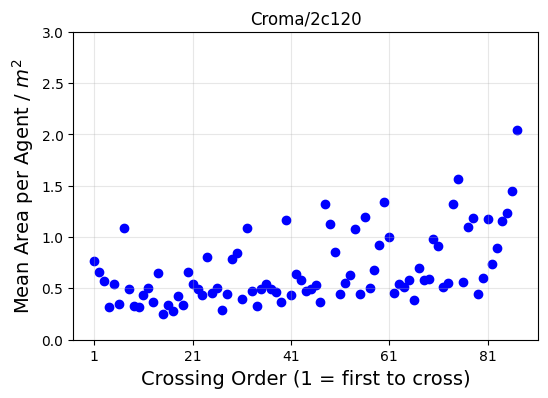

In [53]:
experiment_files =[ "../trajectories_croma/1C070_cam6_cam5_frameshift0_Combined.txt",
                   "../trajectories_croma/2C070_cam6_cam5_frameshift0_Combined.txt",
                   "../trajectories_croma/1C060_cam6_cam5_frameshift0_Combined.txt",
                   "../trajectories_croma/2C120_cam6_cam5_frameshift0_Combined.txt",
                   #"../trajectories_croma/2C130_cam6_cam5_frameshift0_Combined.txt", Problem
                   #"../trajectories_croma/2C150_cam6_cam5_frameshift0_Combined.txt", Problem
                   #../trajectories_croma/2C150_cam6_cam5_frameshift0_Combined.txt",
                   #../trajectories_croma/2C020_cam6_cam5_frameshift0_Combined.txt"

    ]

for experiment_file in experiment_files:    
    print(f"Processing experiment: {title_high}")
    df, density_over_time, crossing_info, individual, title = (
        process_experiment_file(experiment_file, walkable_area)
    )   
    plt.figure(figsize=(6, 4))
    plt.scatter(
        df["order"], df["area"], color="blue"   
    )

    plt.xlabel("Crossing Order (1 = first to cross)", size=14)
    plt.ylabel(r"Mean Area per Agent / $m^2$", size=14)
    plt.title(title)
    plt.ylim([0, 3])
    plt.grid(True, alpha=0.3)
    max_order = df["order"].max()
    plt.xticks(range(1, max_order + 1, 20))

    plt.savefig(f"index_area_figs/area_order_{title.replace("/", "_")}.pdf", bbox_inches="tight")
    print(">> ", f"index_area_figs/area_order_{title.replace('/', '_')}.pdf")
    plt.show()

(-9.739, 9.159, -13.0525, 29.9025)

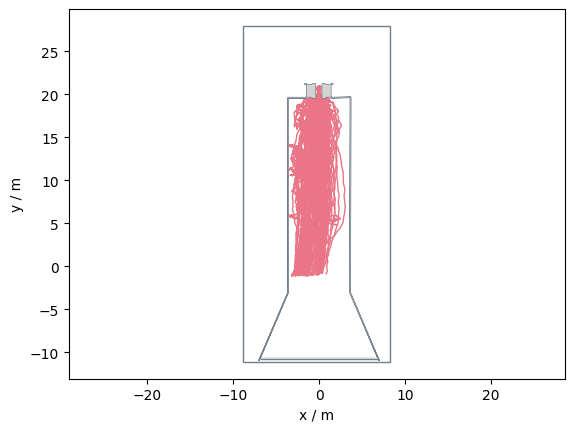

In [46]:
traj = pedpy.load_trajectory_from_txt(trajectory_file=Path("../trajectories_croma/2C130_cam6_cam5_frameshift0_Combined.txt"))
pedpy.plot_measurement_setup(traj=traj, walkable_area=walkable_area).axis('equal')

In [ ]:
compute_individual_voronoi_polygons(
    traj_data=traj,
    walkable_area=walkable_area,
    cut_off=Cutoff(radius=1, quad_segments=3),
)
)

KeyboardInterrupt: 

In [50]:
pedpy.get_invalid_trajectory(
    traj_data=traj,
    walkable_area=walkable_area,)

,id,frame,x,y,point
138374,14,10634,0.456465,19.571200,POINT (0.4564647701518067 19.571199636519136)
138375,14,10635,0.456960,19.576811,POINT (0.4569595253367544 19.57681103271328)
138376,14,10636,0.456648,19.583121,POINT (0.4566483919178961 19.58312071840924)
138377,14,10637,0.454643,19.588331,POINT (0.4546431761813128 19.58833066067992)
138378,14,10638,0.453751,19.594342,POINT (0.4537506516998075 19.59434188582425)
138379,14,10639,0.452060,19.600654,POINT (0.4520595745135771 19.60065445798589)
138380,14,10640,0.450517,19.606969,POINT (0.4505171180243746 19.6069686551208)
138381,14,10641,0.449190,19.613483,POINT (0.4491896850545221 19.61348255291854)
138382,14,10642,0.447187,19.620200,POINT (0.4471869989309386 19.62020021381227)
138383,14,10643,0.445291,19.626620,POINT (0.4452911962796664 19.626620098353644)


In [51]:
help(pedpy.get_invalid_trajectory)

Help on function get_invalid_trajectory in module pedpy.methods.method_utils:

get_invalid_trajectory(*, traj_data: pedpy.data.trajectory_data.TrajectoryData, walkable_area: pedpy.data.geometry.WalkableArea) -> pandas.core.frame.DataFrame
    Returns all trajectory data points outside the given walkable area.

    Args:
        traj_data (TrajectoryData): trajectory data
        walkable_area (WalkableArea): walkable area in which the pedestrians
            should be

    Returns:
        DataFrame showing all data points outside the given walkable area

